# Report

## Metrics analysis

In [220]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np

In [221]:
root = Path.cwd().parent
metrics_data = pd.read_csv(f"{root}/results/metrics/results_20260212_222530.csv")
data_test = pd.read_csv(f"{root}/data/test.csv")

In [222]:
metrics_data.head()

,model,scaler,balancing_name,training_time,cv_roc_auc,best_params
0,LogisticRegression,passthrough,passthrough,162.690065,0.885381,"{'clf__C': np.float64(8.039414069381989), 'clf..."
1,LogisticRegression,passthrough,RandomOverSampler,167.843333,0.887011,"{'clf__C': np.float64(0.5027721293028308), 'cl..."
2,LogisticRegression,passthrough,RandomUnderSampler,165.412093,0.885766,"{'clf__C': np.float64(0.11767157563067113), 'c..."
3,LogisticRegression,passthrough,SMOTE,179.166683,0.886819,"{'clf__C': np.float64(0.7888533630810267), 'cl..."
4,LogisticRegression,StandardScaler,passthrough,171.769382,0.885341,"{'clf__C': np.float64(9.960862878398098), 'clf..."


In [223]:
metrics_data.describe()

,training_time,cv_roc_auc
count,96.000000,96.000000
mean,174.636021,0.894491
std,126.016772,0.033513
min,3.659375,0.811971
25%,124.326160,0.878992
50%,168.664812,0.912147
75%,215.418317,0.921146
max,493.705025,0.928029


### Roc acurracy metrics data

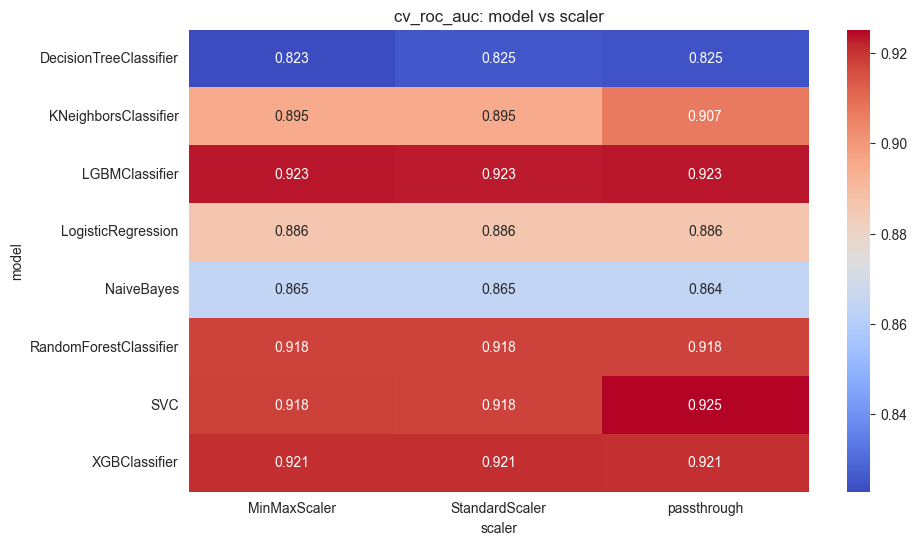

In [224]:
# Pivot do heatmap
pivot_roc = metrics_data.pivot_table(
    values='cv_roc_auc',
    index='model',
    columns='scaler',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("cv_roc_auc: model vs scaler")
plt.show()


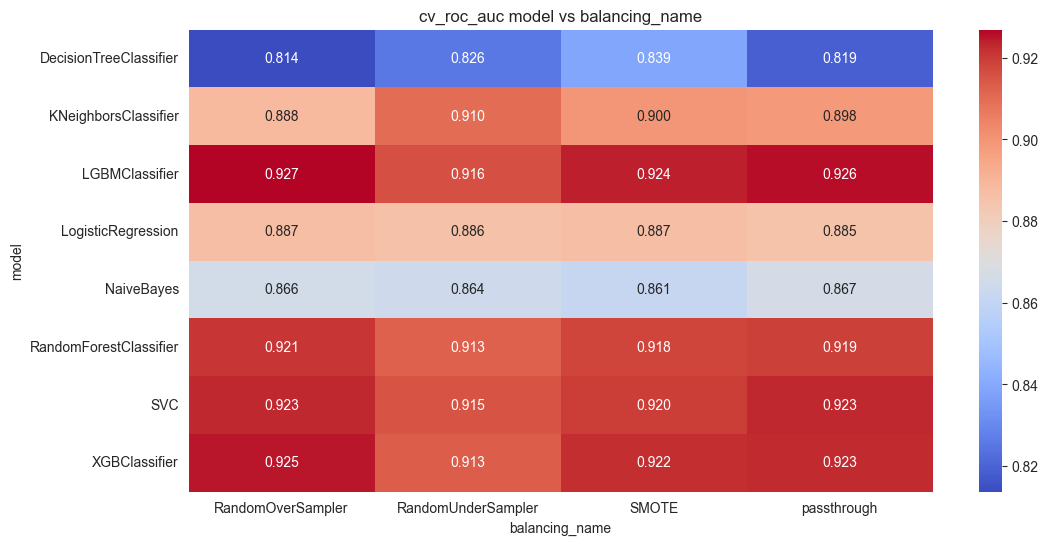

In [225]:
pivot_roc = metrics_data.pivot_table(
    values='cv_roc_auc',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("cv_roc_auc model vs balancing_name")
plt.show()

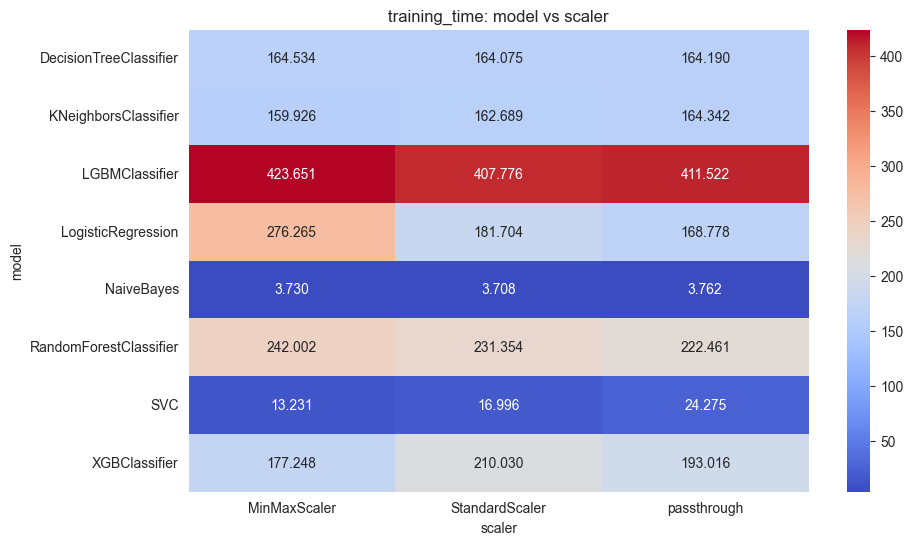

In [226]:
pivot_roc = metrics_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()


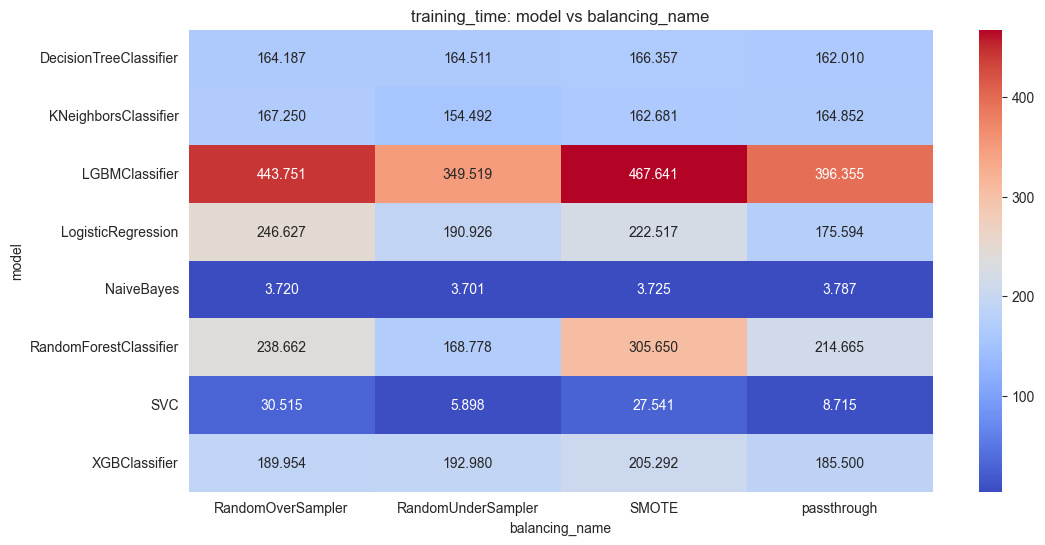

In [227]:
pivot_roc = metrics_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()

## Valid data results

In [228]:
valid_data = pd.read_csv(f"{root}/results/predictions/results_20260217_170541.csv")

In [229]:
valid_data.head()

,model,scaler,balancing_name,training_time,predictions,y_proba
0,LogisticRegression,passthrough,passthrough,1.931007,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.03856774342601274, 0.00886755494368915, 0.2..."
1,LogisticRegression,passthrough,RandomOverSampler,2.198409,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2057018684144178, 0.06838745671221828, 0.71..."
2,LogisticRegression,passthrough,RandomUnderSampler,1.660506,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2972236516143371, 0.0924612826470188, 0.621..."
3,LogisticRegression,passthrough,SMOTE,1.933635,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.21820838755994534, 0.050106305603223426, 0...."
4,LogisticRegression,StandardScaler,passthrough,1.708289,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.038656455517313296, 0.008888903028552657, 0..."


In [230]:
valid_data.describe()

,training_time
count,96.000000
mean,3.105634
std,2.157848
min,1.660506
25%,1.748399
50%,2.136025
75%,3.383715
max,10.805303


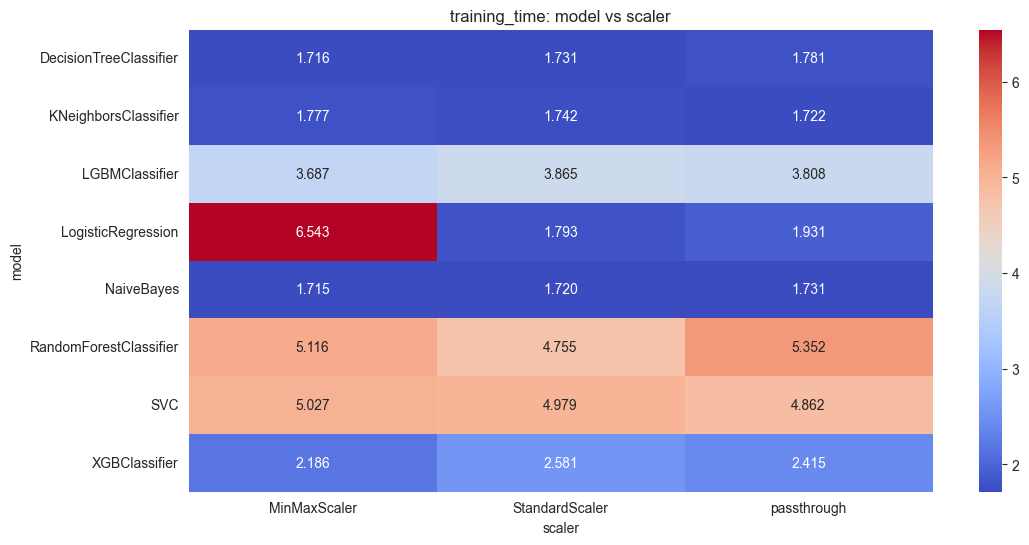

In [231]:
pivot_roc = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()

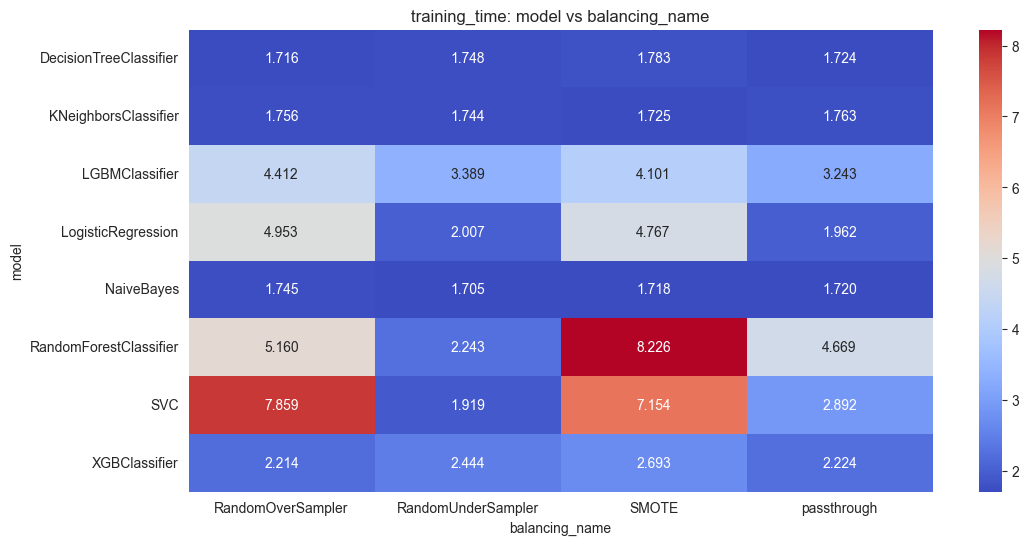

In [232]:
pivot_roc = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()

In [233]:
valid_data["predictions"] = valid_data["predictions"].apply(ast.literal_eval)
valid_data["y_proba"] = valid_data["y_proba"].apply(ast.literal_eval)


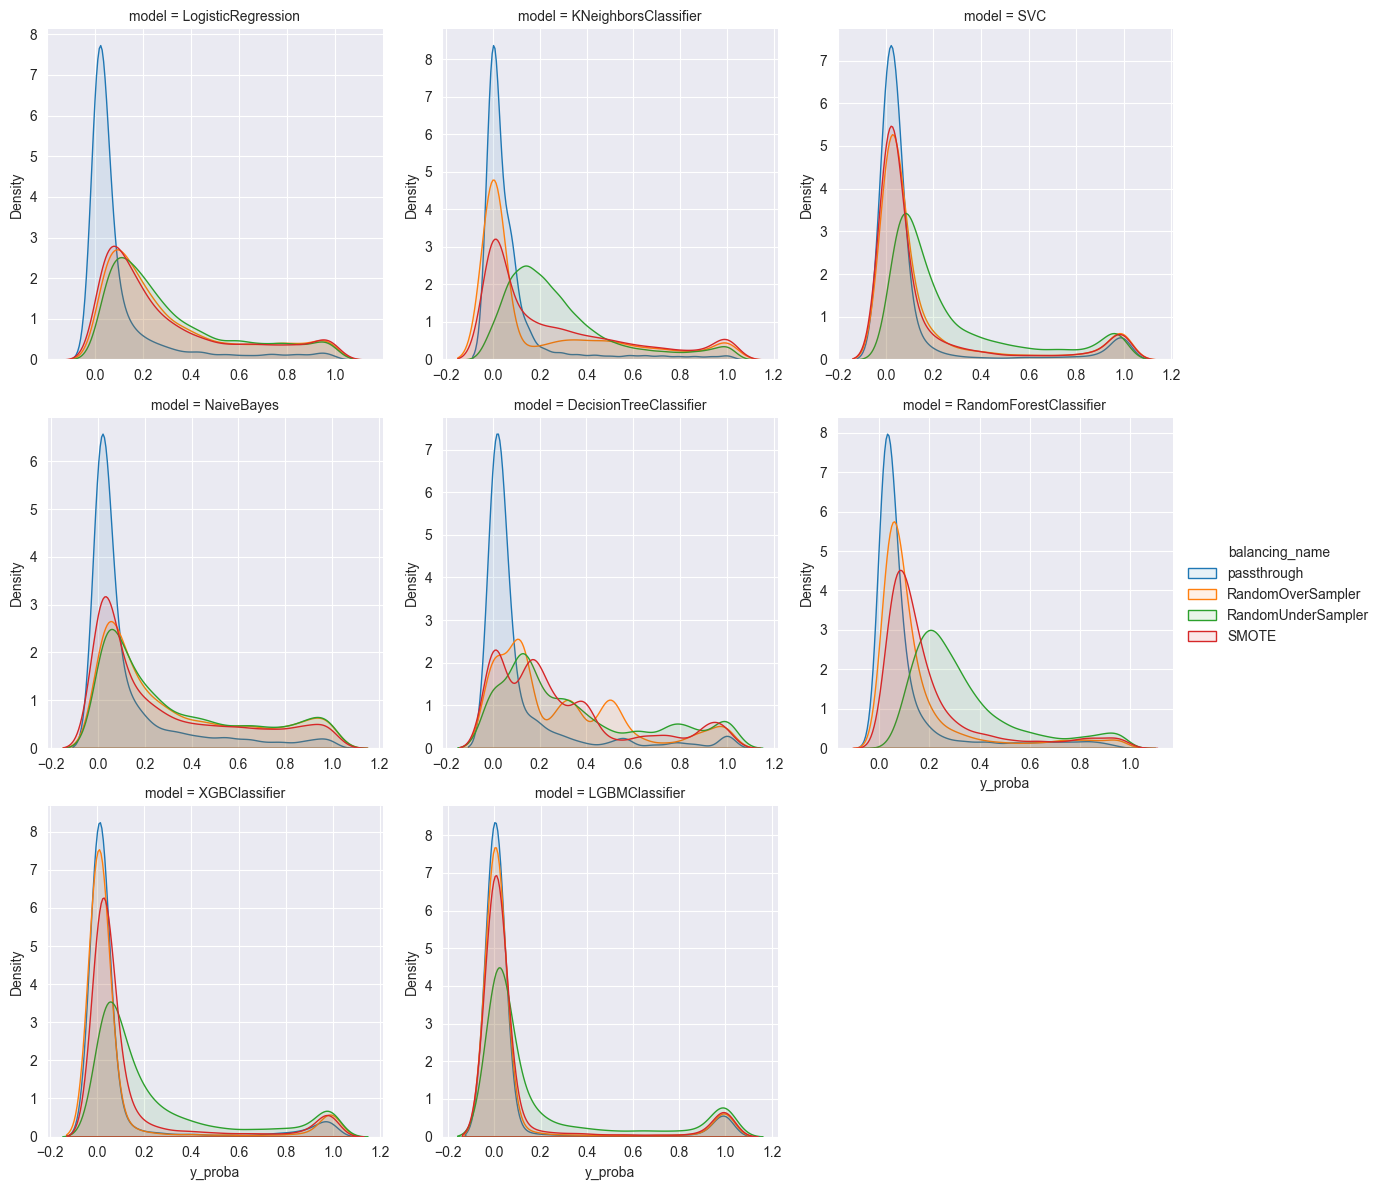

In [234]:
valid_long = valid_data.explode('y_proba')

valid_long['y_proba'] = valid_long['y_proba'].astype(float)

g = sns.FacetGrid(valid_long, col="model", hue="balancing_name", col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.kdeplot, "y_proba", fill=True, alpha=0.1)
g.add_legend()
plt.show()


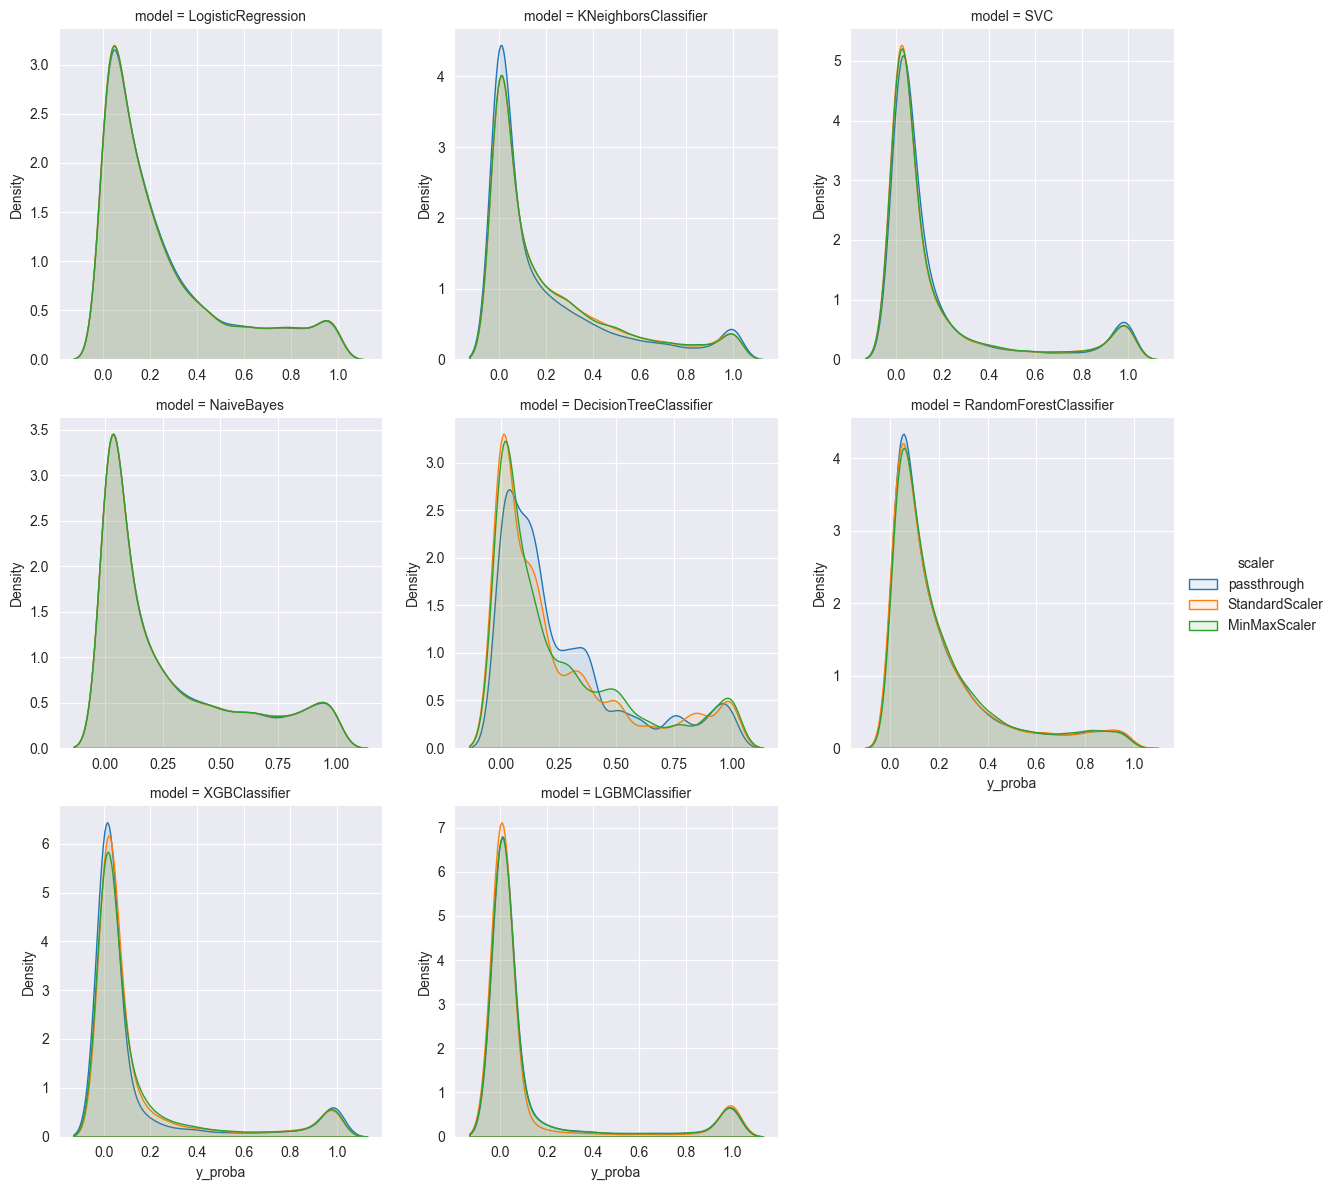

In [235]:
if isinstance(valid_data['y_proba'].iloc[0], str):
    valid_data['y_proba'] = valid_data['y_proba'].apply(ast.literal_eval)

valid_long = valid_data.explode('y_proba')

valid_long['y_proba'] = valid_long['y_proba'].astype(float)

g = sns.FacetGrid(valid_long, col="model", hue="scaler", col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.kdeplot, "y_proba", fill=True, alpha=0.1)
g.add_legend()

plt.show()

## Test data

In [236]:
test_data = pd.read_csv(f"{root}/results/predictions/results_20260217_174409.csv")

In [237]:
test_data.head()

,model,scaler,balancing_name,training_time,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
0,LogisticRegression,passthrough,passthrough,2.048572,0.927667,0.789474,0.488166,0.603291,0.868898
1,LogisticRegression,passthrough,RandomOverSampler,2.191814,0.842667,0.400298,0.795858,0.532673,0.868901
2,LogisticRegression,passthrough,RandomUnderSampler,1.731734,0.839333,0.394428,0.795858,0.527451,0.865841
3,LogisticRegression,passthrough,SMOTE,1.932253,0.845000,0.404511,0.795858,0.536391,0.868651
4,LogisticRegression,StandardScaler,passthrough,1.730944,0.927333,0.788462,0.485207,0.600733,0.868868


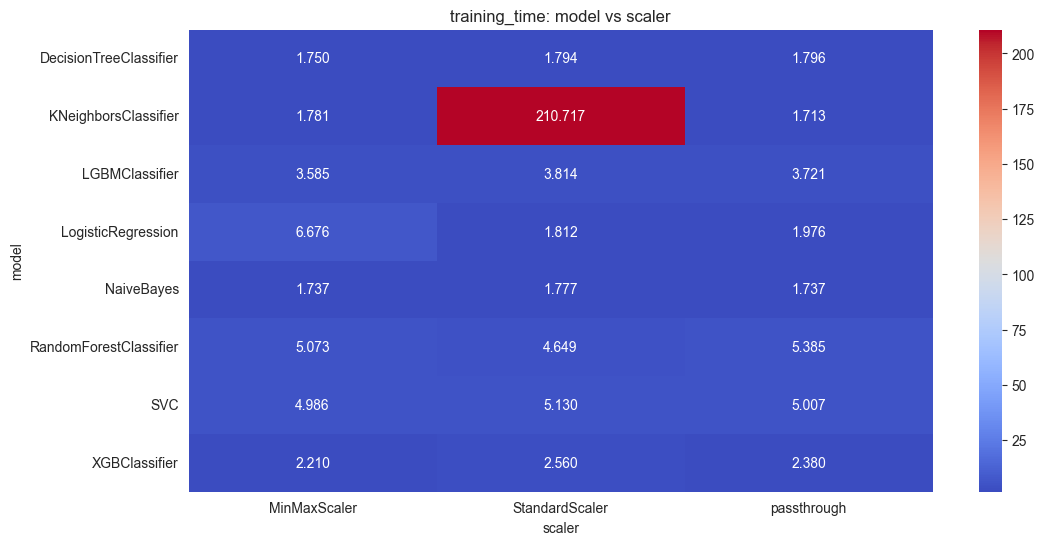

In [238]:
pivot_roc = test_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()

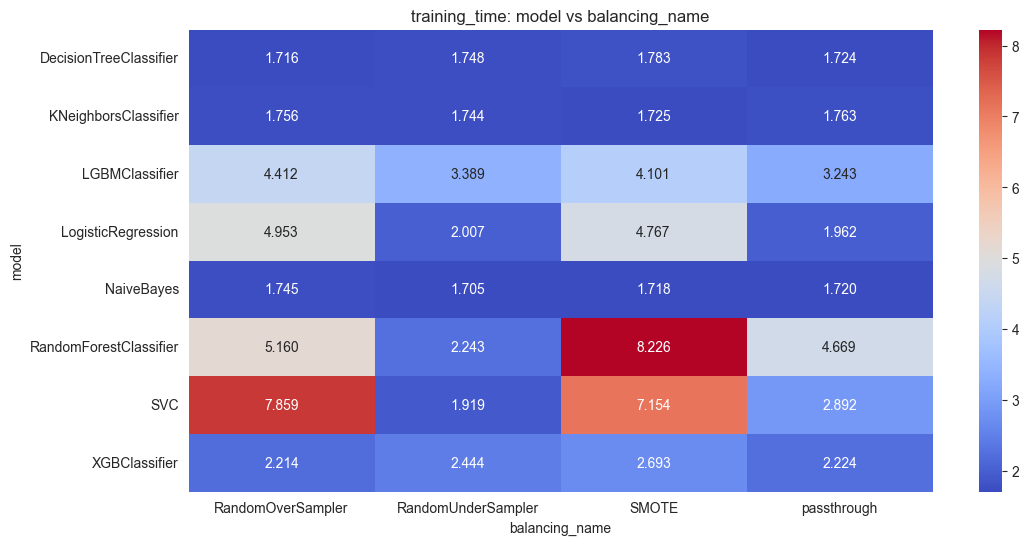

In [239]:
pivot_roc = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_roc, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()

In [240]:
scaler_analysis_accuracy_score = test_data.groupby(['model', "scaler"])['accuracy_score'].mean()
scaler_analysis_precision_score = test_data.groupby(['model', "scaler"])['precision_score'].mean()
scaler_analysis_recall_score = test_data.groupby(['model', "scaler"])['recall_score'].mean()
scaler_analysis_f1_score = test_data.groupby(['model', "scaler"])['f1_score'].mean()
scaler_analysis_roc_auc_score = test_data.groupby(['model', "scaler"])['roc_auc_score'].mean()

sampler_analysis_accuracy_score = test_data.groupby(['model', "balancing_name"])['accuracy_score'].mean()
sampler_analysis_precision_score = test_data.groupby(['model', "balancing_name"])['precision_score'].mean()
sampler_analysis_recall_score = test_data.groupby(['model', "balancing_name"])['recall_score'].mean()
sampler_analysis_f1_score = test_data.groupby(['model', "balancing_name"])['f1_score'].mean()
sampler_analysis_roc_auc_score = test_data.groupby(['model', "balancing_name"])['roc_auc_score'].mean()

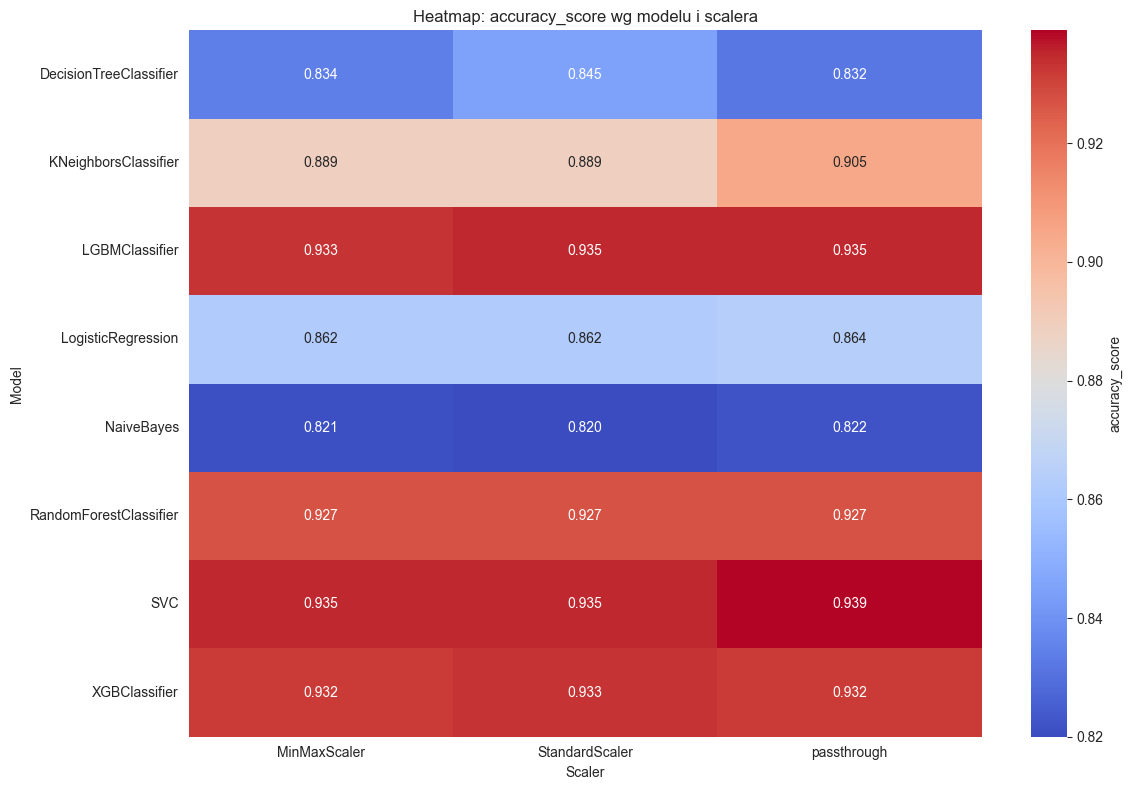

In [241]:
# Pivot do tabeli model x scaler
pivot = scaler_analysis_accuracy_score.reset_index().pivot(
    index='model', columns='scaler', values='accuracy_score'
).round(3)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f',
            cbar_kws={'label': 'accuracy_score'})
plt.title("Heatmap: accuracy_score wg modelu i scalera")
plt.ylabel("Model")
plt.xlabel("Scaler")
plt.tight_layout()
plt.show()


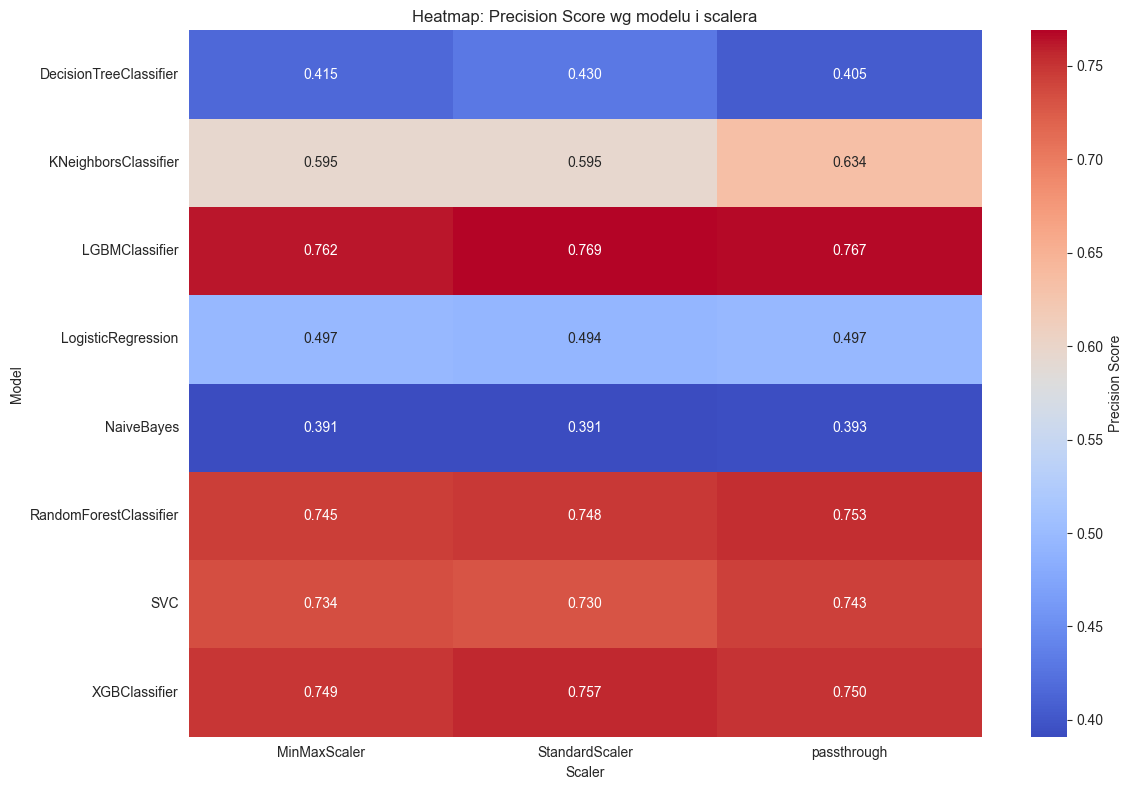

In [242]:
# SCALER - precision_score
pivot = scaler_analysis_precision_score.reset_index().pivot(index='model', columns='scaler',
                                                            values='precision_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Precision Score'})
plt.title("Heatmap: Precision Score wg modelu i scalera")
plt.ylabel("Model");
plt.xlabel("Scaler");
plt.tight_layout();
plt.show()

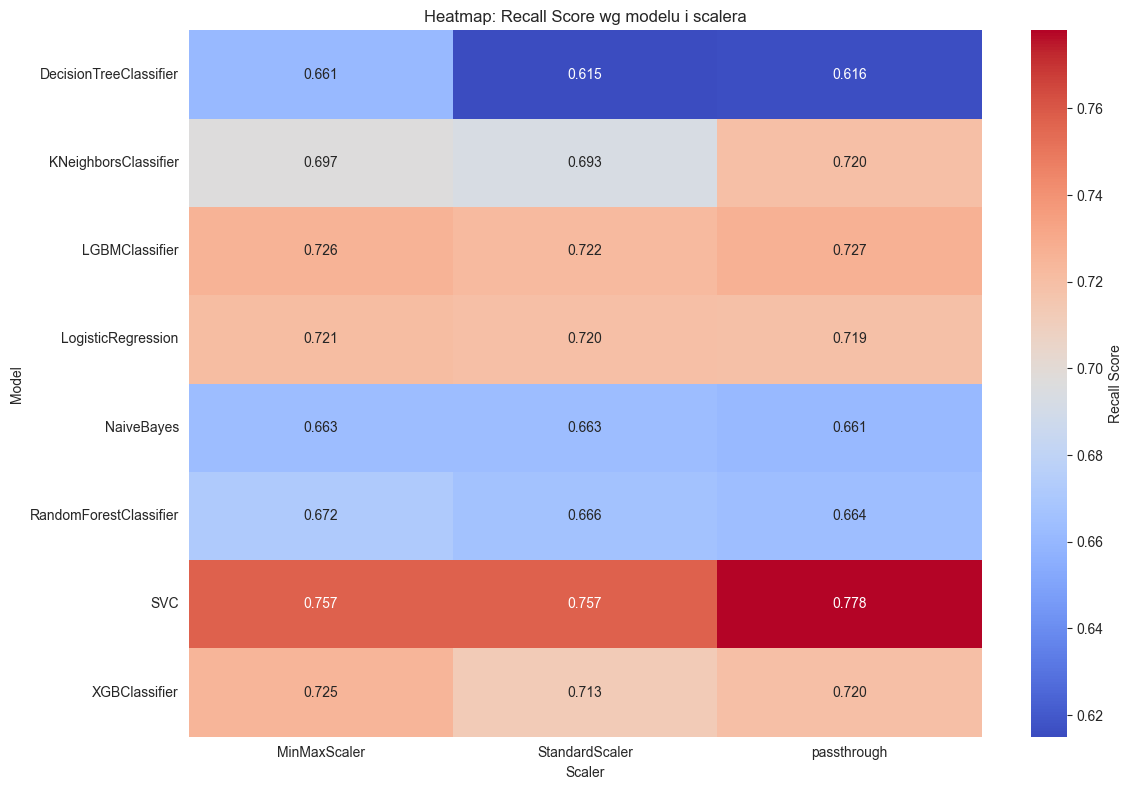

In [243]:
pivot = scaler_analysis_recall_score.reset_index().pivot(index='model', columns='scaler', values='recall_score').round(
    3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Recall Score'})
plt.title("Heatmap: Recall Score wg modelu i scalera")
plt.ylabel("Model");
plt.xlabel("Scaler");
plt.tight_layout();
plt.show()

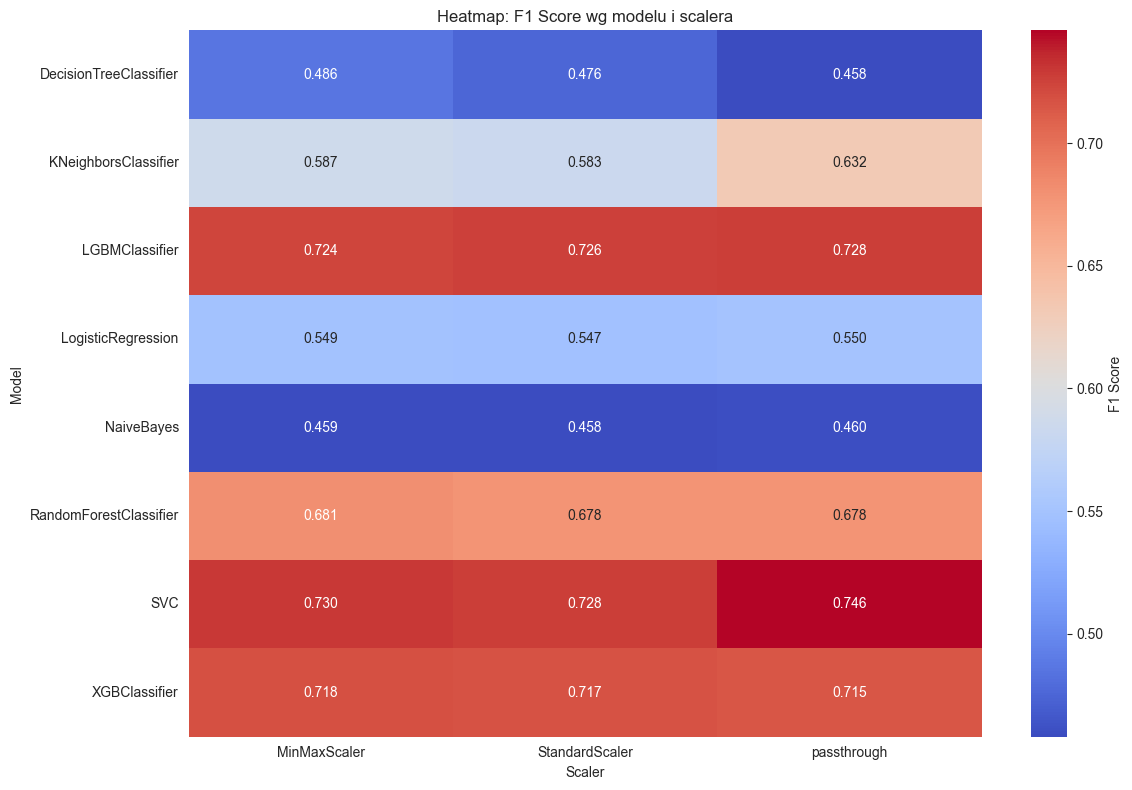

In [244]:
pivot = scaler_analysis_f1_score.reset_index().pivot(index='model', columns='scaler', values='f1_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'F1 Score'})
plt.title("Heatmap: F1 Score wg modelu i scalera")
plt.ylabel("Model");
plt.xlabel("Scaler");
plt.tight_layout();
plt.show()

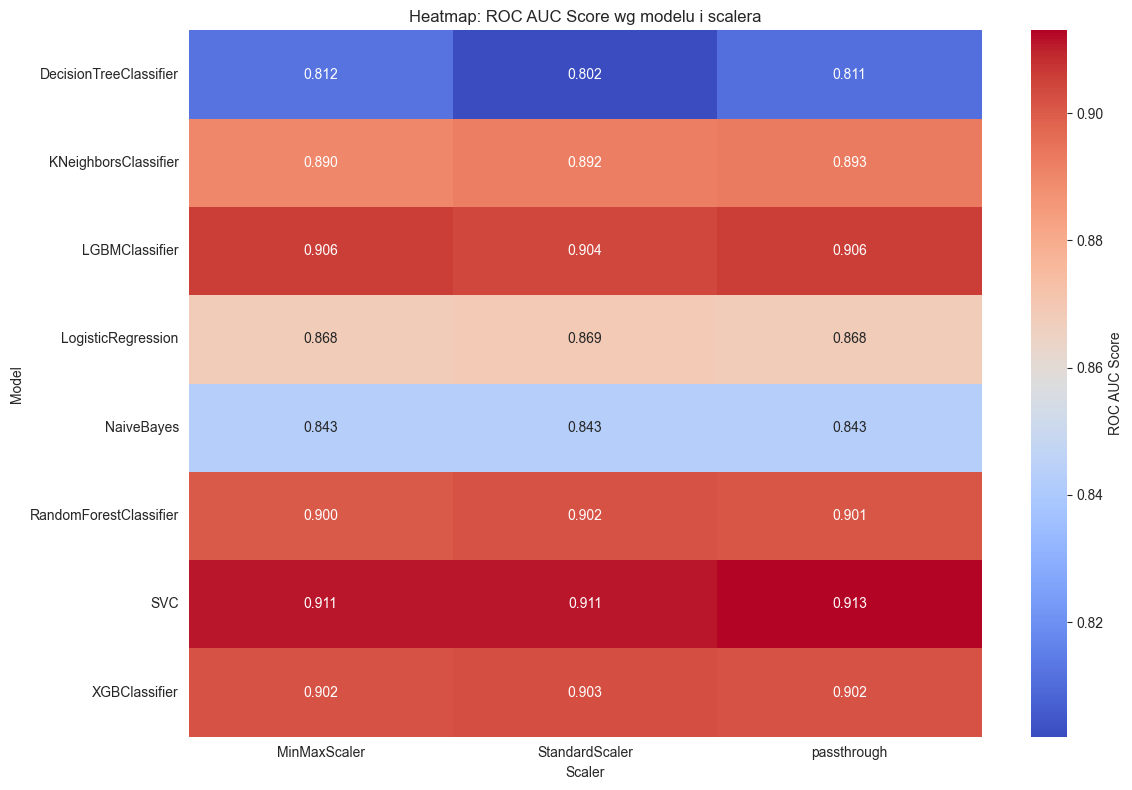

In [245]:
pivot = scaler_analysis_roc_auc_score.reset_index().pivot(index='model', columns='scaler',
                                                          values='roc_auc_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'ROC AUC Score'})
plt.title("Heatmap: ROC AUC Score wg modelu i scalera")
plt.ylabel("Model");
plt.xlabel("Scaler");
plt.tight_layout();
plt.show()

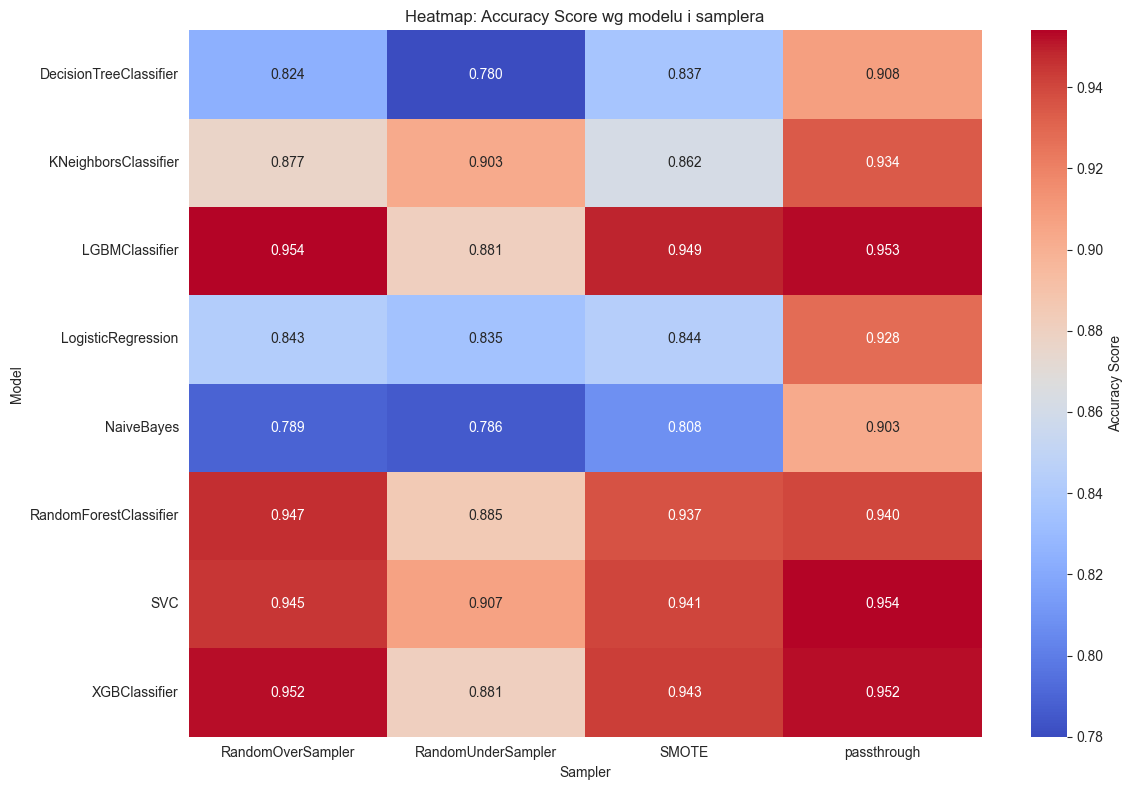

In [246]:
pivot = sampler_analysis_accuracy_score.reset_index().pivot(index='model', columns='balancing_name',
                                                            values='accuracy_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Accuracy Score'})
plt.title("Heatmap: Accuracy Score wg modelu i samplera")
plt.ylabel("Model");
plt.xlabel("Sampler");
plt.tight_layout();
plt.show()


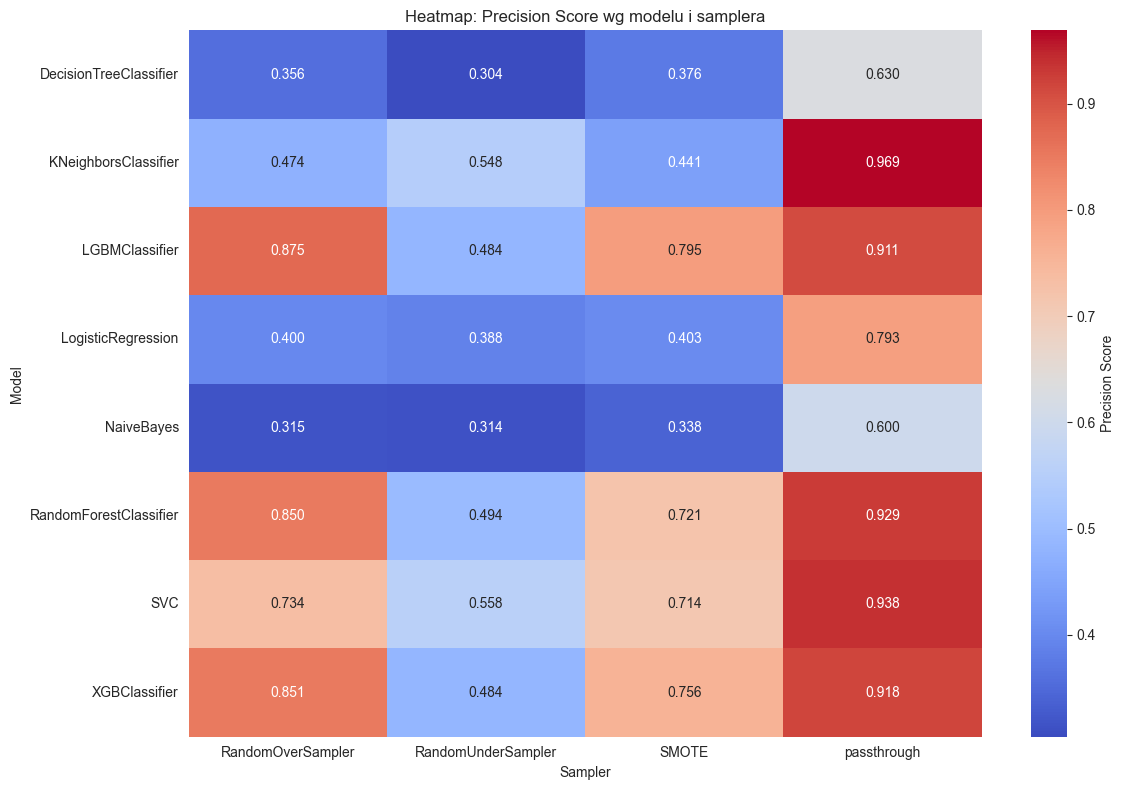

In [247]:
pivot = sampler_analysis_precision_score.reset_index().pivot(index='model', columns='balancing_name',
                                                             values='precision_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Precision Score'})
plt.title("Heatmap: Precision Score wg modelu i samplera")
plt.ylabel("Model");
plt.xlabel("Sampler");
plt.tight_layout();
plt.show()

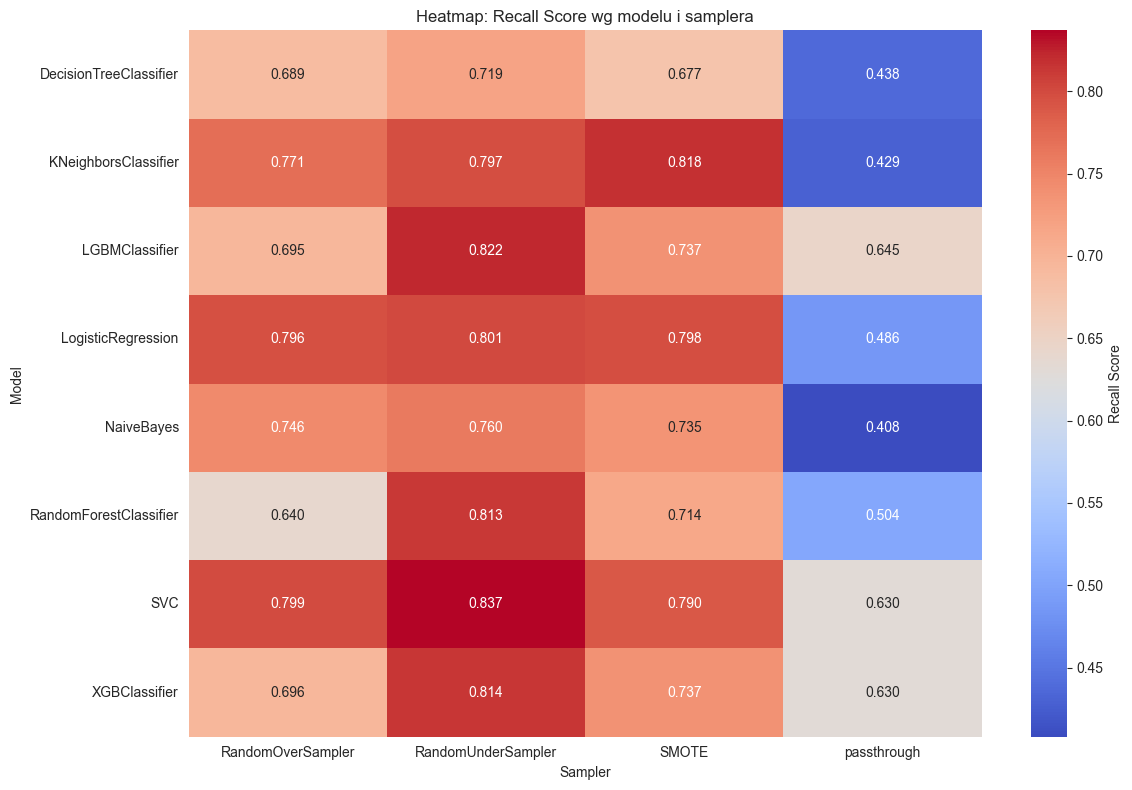

In [248]:
pivot = sampler_analysis_recall_score.reset_index().pivot(index='model', columns='balancing_name',
                                                          values='recall_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Recall Score'})
plt.title("Heatmap: Recall Score wg modelu i samplera")
plt.ylabel("Model");
plt.xlabel("Sampler");
plt.tight_layout();
plt.show()

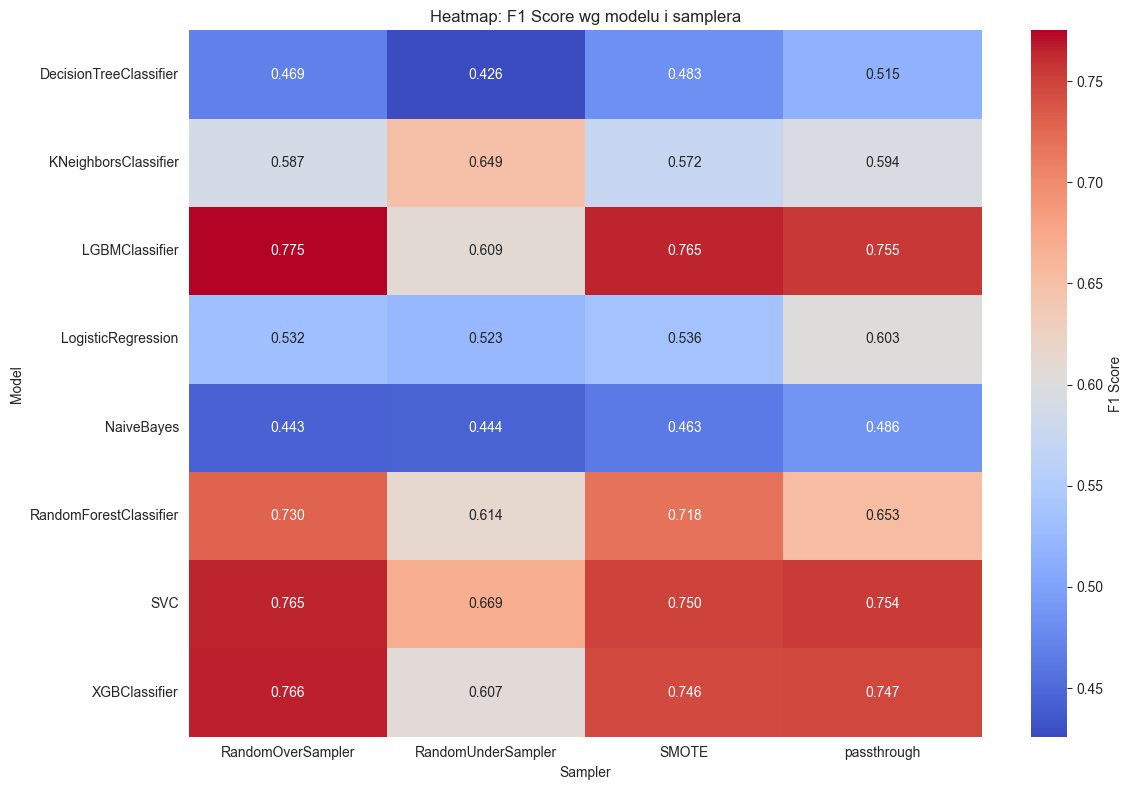

In [249]:
pivot = sampler_analysis_f1_score.reset_index().pivot(index='model', columns='balancing_name', values='f1_score').round(
    3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'F1 Score'})
plt.title("Heatmap: F1 Score wg modelu i samplera")
plt.ylabel("Model");
plt.xlabel("Sampler");
plt.tight_layout();
plt.show()

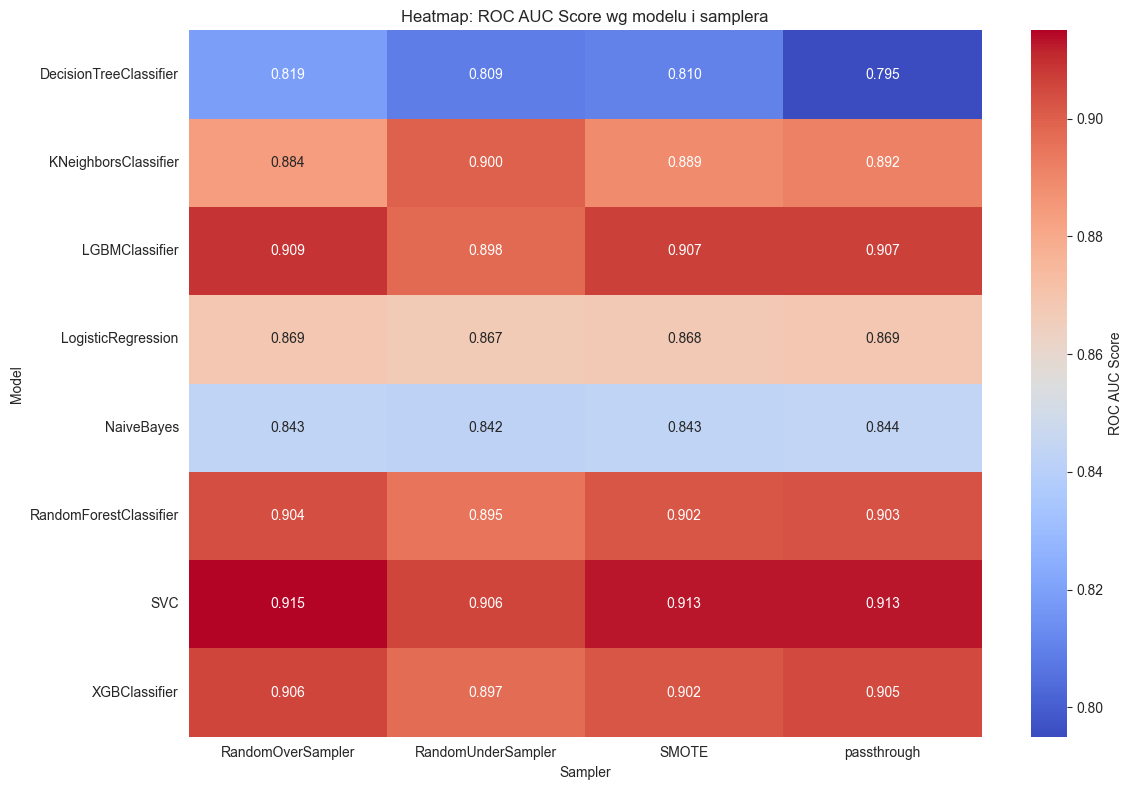

In [250]:
pivot = sampler_analysis_roc_auc_score.reset_index().pivot(index='model', columns='balancing_name',
                                                           values='roc_auc_score').round(3)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'ROC AUC Score'})
plt.title("Heatmap: ROC AUC Score wg modelu i samplera")
plt.ylabel("Model");
plt.xlabel("Sampler");
plt.tight_layout();
plt.show()